# Probabilities through the Earth

Putting PREM and the slab machinery together: oscillations for neutrinos that have crossed the Earth, and between two points on its surface.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import earth

## Against zenith angle

At fixed energy, sweeping $\cos\theta_z$ from $0$ (horizontal) to $-1$ (straight through the centre) traces out the matter effect as the neutrino passes through progressively denser material.

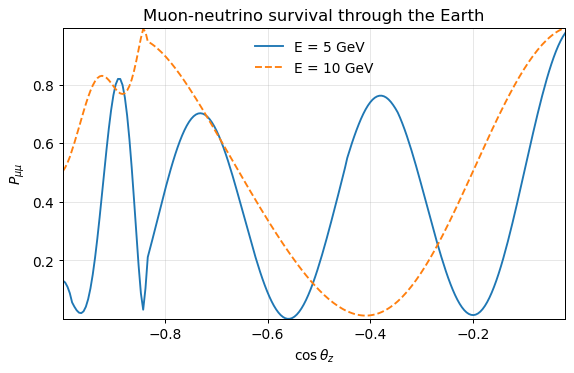

In [3]:
costhz = np.linspace(-0.999, -0.02, 220)

for e_gev, style in ((5.0, "-"), (10.0, "--")):
    p = np.array([earth.probabilities_3nu_earth(
        H_VAC_3NU, e_gev*GEV, c, n_slabs_per_segment=6)
        for c in costhz])
    plt.plot(costhz, p[:, 4], style,
             label="E = %.0f GeV" % e_gev)

plt.xlabel(r"$\cos\theta_z$")
plt.ylabel(r"$P_{\mu\mu}$")
plt.title("Muon-neutrino survival through the Earth")
plt.legend()
plt.show()

The core-mantle boundary leaves a visible feature: near $\cos\theta_z \approx -0.83$ the trajectory starts to clip the outer core, and the density it crosses jumps.

## An Earth oscillogram

Energy against zenith angle — the map an atmospheric-neutrino experiment measures.

**This used to have to loop, and no longer does.** Before 1.12.0 `probabilities_3nu_earth` took one energy and one zenith angle, so a grid meant a Python loop over every point of it, and this notebook said so. Both arguments may now be arrays, and they broadcast: index the energies and the angles on different axes and the whole map comes back on the grid, in one call.

What has *not* changed is `slabs.probabilities_3nu_slabs`, which still expects one Hamiltonian per slab rather than a stack of them per slab. The number and position of the slabs depend on the trajectory, so a set of energies through *different* zenith angles is genuinely not a rectangular array of Hamiltonians. `earth` deals with that by taking one angle at a time internally — every energy at a given angle shares the geometry and the matter potentials, which is where the saving comes from.

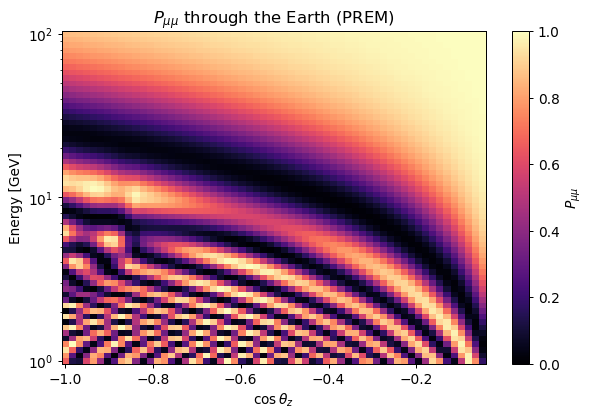

In [4]:
n_e, n_c = 60, 60
E_gev = np.logspace(0.0, 2.0, n_e)
cz = np.linspace(-0.999, -0.05, n_c)

# One call: energies down one axis, angles across the other.  The
# trailing axis holds the nine probabilities; index 4 is P_mumu.
grid = earth.probabilities_3nu_earth(
    H_VAC_3NU, (E_gev*GEV)[:, None], cz[None, :],
    n_slabs_per_segment=4)[..., 4]

fig, ax = plt.subplots(figsize=(7.6, 4.8))
mesh = ax.pcolormesh(cz, E_gev, grid, shading="auto",
                     cmap="magma", vmin=0.0, vmax=1.0)
ax.set_yscale("log")
ax.set_xlabel(r"$\cos\theta_z$")
ax.set_ylabel("Energy [GeV]")
ax.set_title(r"$P_{\mu\mu}$ through the Earth (PREM)")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=r"$P_{\mu\mu}$")
plt.show()

### One subdivision for the whole map

The map above fixes `n_slabs_per_segment=4`, chosen the way such numbers usually are — by eye. `slabs_for_tolerance` chooses it instead, from a stated accuracy. Handed the whole grid it returns one subdivision that covers every point of it, set by the worst-converging one; and because the search costs about twice a single evaluation, it is worth calling once for the map rather than per point.

In [5]:
atol = 1.0e-4
n = earth.slabs_for_tolerance(
    H_VAC_3NU, (E_gev*GEV)[:, None], cz[None, :], atol=atol)
print("one subdivision for the whole %dx%d map at atol=%.0e:  n = %d"
      % (n_e, n_c, atol, n))

refined = earth.probabilities_3nu_earth(
    H_VAC_3NU, (E_gev*GEV)[:, None], cz[None, :], n)[..., 4]
print("largest change against the n=4 map above:  %.2e"
      % np.max(np.abs(refined-grid)))

one subdivision for the whole 60x60 map at atol=1e-04:  n = 128
largest change against the n=4 map above:  2.54e-02


That difference is worth reading twice. The map above, drawn at `n_slabs_per_segment=4`, differs from the refined one by a few times $10^{-2}$ in $P_{\mu\mu}$ — visible on the colour scale, and far larger than anything an analysis would accept. It is fine for a picture of where the resonance sits, which is what this notebook wants; it is not fine for fitting. Choosing the subdivision from a tolerance rather than by eye is how that distinction stops being invisible.

## Between two places

The library knows a set of named locations — the same set as the sibling Magnus package — and will work out the chord between any two of them.

In [6]:
print("known locations:")
print("  " + ", ".join(sorted(earth.LOC_COORDS_DMS)))

known locations:
  baikal, cern, desy, ess, fermilab, gran_sasso, homestake, kamioka, km3net_arca, km3net_orca, north_pole, pyhaasalmi, snolab, south_pole, tokai


In [7]:
pairs = [("cern", "gran_sasso"),
         ("fermilab", "homestake"),
         ("tokai", "kamioka"),
         ("cern", "kamioka"),
         ("south_pole", "north_pole")]

print("%-26s %10s %12s" % ("baseline", "chord [km]", "cos(theta_z)"))
for a, b in pairs:
    la, lo = earth.coordinates_of_named_location(a)
    lb, ob = earth.coordinates_of_named_location(b)
    d = earth.chord_length_inside_earth(la, lo, lb, ob)
    c = earth.costhz_between_points_on_surface(la, lo, lb, ob)
    print("%-26s %10.1f %12.4f" % (a+" -> "+b, d, c))

baseline                   chord [km] cos(theta_z)
cern -> gran_sasso              728.6      -0.0572
fermilab -> homestake          1284.7      -0.1008
tokai -> kamioka                294.7      -0.0231
cern -> kamioka                8726.9      -0.6849
south_pole -> north_pole      12742.0      -1.0000


These are a check on the geometry, not just a convenience. The chords come out at the baselines the experiments actually quote: CERN to Gran Sasso is the 730 km of CNGS, Tokai to Kamioka the 295 km of T2K, and pole to pole is exactly one Earth diameter. Fermilab to Homestake gives 1285 km against DUNE's quoted 1300 km, the difference being that DUNE quotes the distance to the detector hall rather than the surface chord.

And the probability along one of those trajectories, against energy:

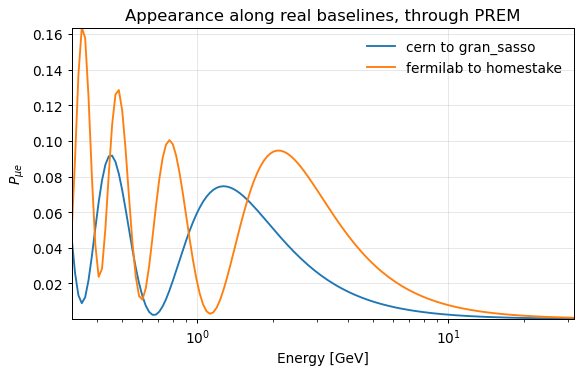

In [8]:
E_gev = np.logspace(-0.5, 1.5, 150)

fig, ax = plt.subplots()
for a, b in (("cern", "gran_sasso"), ("fermilab", "homestake")):
    p = np.array([earth.probabilities_3nu_between_locations(
        H_VAC_3NU, e*GEV, a, b, n_slabs_per_segment=6)
        for e in E_gev])
    ax.semilogx(E_gev, p[:, 3], label="%s to %s" % (a, b))

ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Appearance along real baselines, through PREM")
ax.legend()
plt.show()

---

**Previous:** [The Earth: PREM, chords, and slabs](06_earth_and_prem.ipynb)  
**Next:** [Unusual density profiles](08_unusual_density_profiles.ipynb) --- castle walls, and why the arrangement of matter matters  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)